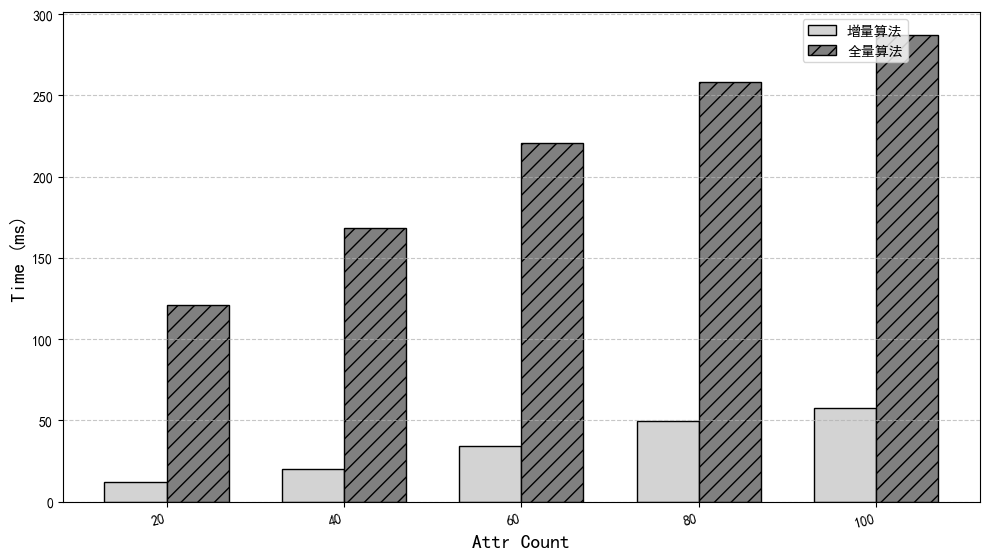

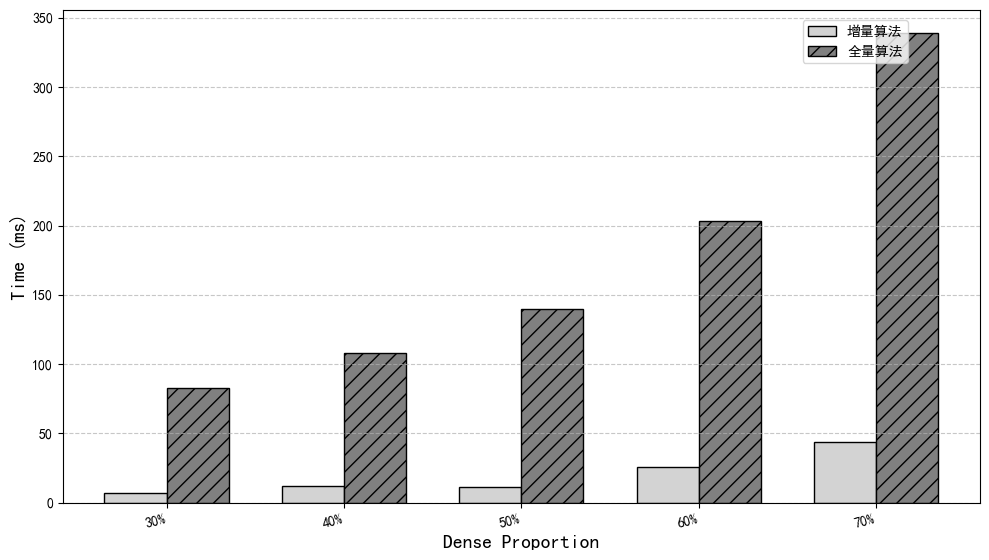

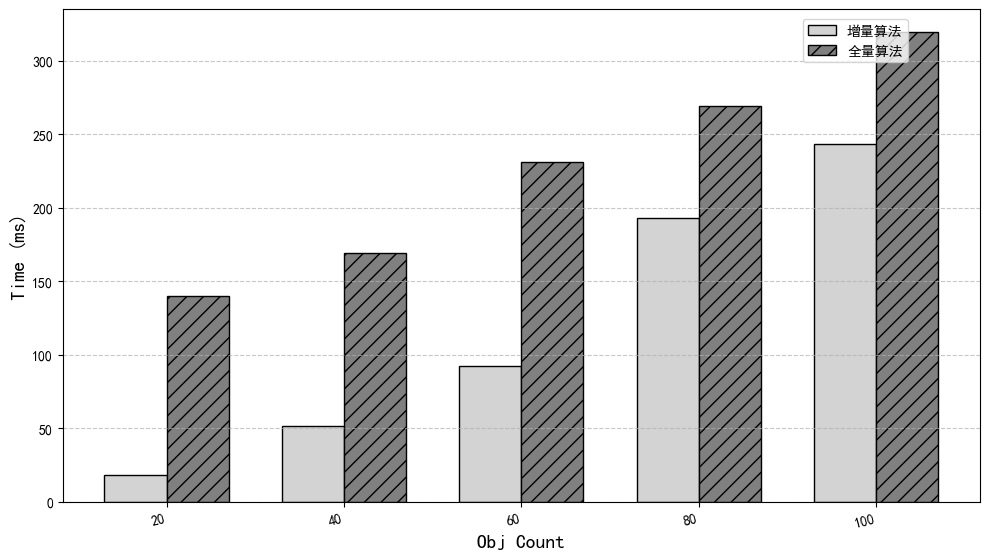

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import re

# 设置支持中文的字体，避免标签显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Songti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def read_and_average(filepath):
    """
    读取文件并计算两列的平均值
    """
    col1, col2 = [], []
    if os.path.exists(filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    parts = line.split(',')
                    if len(parts) == 2:
                        col1.append(float(parts[0]))
                        col2.append(float(parts[1]))
    if col1 and col2:
        return np.mean(col1), np.mean(col2)
    return 0, 0

# 1. 使用正则表达式从文件名中动态获取 X 轴坐标
base_dir = '../data/input'
attr_x, obj_x, dense_x = [], [], []

if os.path.exists(base_dir):
    for filename in os.listdir(base_dir):
        # 匹配 attr_数字.txt
        match_attr = re.match(r'attr_(\d+)\.txt', filename)
        if match_attr:
            attr_x.append(int(match_attr.group(1)))
            
        # 匹配 obj_数字.txt
        match_obj = re.match(r'obj_(\d+)\.txt', filename)
        if match_obj:
            obj_x.append(int(match_obj.group(1)))
            
        # 匹配 dense_浮点数.txt
        match_dense = re.match(r'dense_([\d.]+)\.txt', filename)
        if match_dense:
            dense_x.append(float(match_dense.group(1)))

# 对提取的数值进行排序，确保横坐标按从小到大的顺序排列
attr_x.sort()
obj_x.sort()
dense_x.sort()

# 根据排序后的横坐标读取对应的数据
attr_means = [read_and_average(os.path.join(base_dir, f'attr_{x}.txt')) for x in attr_x]
obj_means = [read_and_average(os.path.join(base_dir, f'obj_{x}.txt')) for x in obj_x]
dense_means = [read_and_average(os.path.join(base_dir, f'dense_{x}.txt')) for x in dense_x]

# 解包均值数据
attr_inc, attr_full = zip(*attr_means) if attr_means else ([], [])
obj_inc, obj_full = zip(*obj_means) if obj_means else ([], [])
dense_inc, dense_full = zip(*dense_means) if dense_means else ([], [])

# 2 & 3. 封装统一的绘图函数，按要求输出单独的图且UI风格一致
def plot_independent_chart(x_values, inc_data, full_data, xlabel, xticks_labels=None):
    if not x_values:
        return
        
    x = np.arange(len(x_values))
    width = 0.35
    
    # 创建独立的画布，尺寸调整为 10x6
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # 绘制双柱状图，使用参考代码中的UI配色和斜杠
    rects1 = ax1.bar(x - width/2, inc_data, width, label='增量算法', color='lightgray', edgecolor='black')
    rects2 = ax1.bar(x + width/2, full_data, width, label='全量算法', color='gray', edgecolor='black', hatch='//')
    
    # 设置主Y轴标签、X轴标签和格式
    ax1.set_xlabel(xlabel, fontsize=14)
    ax1.set_ylabel('Time (ms)', fontsize=14, color='black')
    ax1.set_xticks(x)
    
    # 判断是否需要自定义标签（比如给dense加百分号）
    if xticks_labels is None:
        xticks_labels = x_values
        
    ax1.set_xticklabels(xticks_labels, rotation=15, ha="right")
    ax1.tick_params(axis='y', labelcolor='black')
    
    # 添加水平网格线，帮助读者更好地比较数值
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 添加图例，放置在图表内部的右上角
    fig.legend(loc='upper right', bbox_to_anchor=(0.92, 0.92), ncol=1)
    
    # 优化布局，防止标签重叠
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    
    # 展示单张独立的图表
    plt.show()

# 依次绘制并输出三张独立的图
# 1. 绘制 attr
plot_independent_chart(attr_x, attr_inc, attr_full, 'Attr Count')

# 2. 绘制 dense (将提取出的小数转换为百分比作为显示标签)
dense_labels = [f"{int(val * 100)}%" for val in dense_x]
plot_independent_chart(dense_x, dense_inc, dense_full, 'Dense Proportion', xticks_labels=dense_labels)

# 3. 绘制 obj
plot_independent_chart(obj_x, obj_inc, obj_full, 'Obj Count')